<a href="https://colab.research.google.com/github/yzhang-data/Fraud_Detection/blob/main/Fraud_Detection_01_Data_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
To perform an extensive exploratory data analysis (EDA) on a transactions dataset. This includes loading the data in chunks, checking for missing values, handling various data types (especially dates and strings), feature engineering time-based and ratio features, and analyzing relationships between different attributes, particularly focusing on fraud detection. The analysis will involve descriptive statistics, distributions, and visualizations to gain insights into the transaction patterns and potential indicators of fraudulent activity.

## Initial Setup and Data Loading

### Takeaway:
Ensure the environment is set up by mounting Google Drive, defining the data path, importing libraries, setting the chunk size, and preparing the data for chunk-wise processing.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Locate Data from Google Drive

%cd /content/drive/My Drive/Fraud

/content/drive/My Drive/Fraud


In [ ]:
# define file path
file_path='/content/drive/My Drive/Fraud/transactions.txt'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
chunk_size = 10000

In [ ]:
# Read sample data for quick check to understand the overall structure and data types

sample_data = pd.read_json(file_path, lines=True, nrows=1000)
sample_data.info()
print(sample_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   accountNumber             1000 non-null   int64  
 1   customerId                1000 non-null   int64  
 2   creditLimit               1000 non-null   int64  
 3   availableMoney            1000 non-null   float64
 4   transactionDateTime       1000 non-null   object 
 5   transactionAmount         1000 non-null   float64
 6   merchantName              1000 non-null   object 
 7   acqCountry                1000 non-null   object 
 8   merchantCountryCode       1000 non-null   object 
 9   posEntryMode              1000 non-null   object 
 10  posConditionCode          1000 non-null   int64  
 11  merchantCategoryCode      1000 non-null   object 
 12  currentExpDate            1000 non-null   object 
 13  accountOpenDate           1000 non-null   object 
 14  dateOfLas

In [ ]:
sample_data.columns

Index(['accountNumber', 'customerId', 'creditLimit', 'availableMoney',
       'transactionDateTime', 'transactionAmount', 'merchantName',
       'acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode',
       'merchantCategoryCode', 'currentExpDate', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'transactionType', 'echoBuffer', 'currentBalance', 'merchantCity',
       'merchantState', 'merchantZip', 'cardPresent', 'posOnPremises',
       'recurringAuthInd', 'expirationDateKeyInMatch', 'isFraud'],
      dtype='object')

## Data Quality Assessment

### Takeaway:
Comprehensively check and handle missing values, including empty strings in object columns.


In [ ]:
total_rows = 0
missing = None
dtypes = None

# Read data using chunks. Adjust chunksize as needed.
chunks = pd.read_json(file_path, lines=True, chunksize=chunk_size)

for i, chunk in enumerate(chunks):

    # Standardize missing values
    chunk = chunk.replace(r"^\s*$", pd.NA, regex=True)

    # Save dtypes from the first chunk
    if i == 0:
        dtypes = chunk.dtypes.astype(str)

    # Total rows
    total_rows += len(chunk)

    # Missing values
    if missing is None:
        missing = chunk.isna().sum()
    else:
        missing += chunk.isna().sum()

# -----------------------------
# Create summary table
# -----------------------------

summary = pd.DataFrame({
    "dtype": dtypes,
    "missing_count": missing,
    "missing_pct": (missing / total_rows * 100).round(2)
})

summary = summary.sort_values(
    by="missing_pct",
    ascending=False
)

print(summary)


                            dtype  missing_count  missing_pct
posOnPremises              object         786363       100.00
recurringAuthInd           object         786363       100.00
merchantState              object         786363       100.00
merchantZip                object         786363       100.00
echoBuffer                 object         786363       100.00
merchantCity               object         786363       100.00
acqCountry                 object           4562         0.58
posEntryMode               object           4054         0.52
transactionType            object            698         0.09
merchantCountryCode        object            724         0.09
posConditionCode           object            409         0.05
transactionDateTime        object              0         0.00
accountNumber               int64              0         0.00
currentExpDate             object              0         0.00
merchantCategoryCode       object              0         0.00
merchant

In [ ]:
# double check columns to drop
sample_chunk = next(
    pd.read_json(
        file_path,
        lines=True,
        chunksize=10000
    )
)

drop_cols = [
    "posOnPremises",
    "recurringAuthInd",
    "merchantState",
    "merchantZip",
    "echoBuffer",
    "merchantCity"
]

sample_chunk[drop_cols].head()

,posOnPremises,recurringAuthInd,merchantState,merchantZip,echoBuffer,merchantCity
0,,,,,,
1,,,,,,
2,,,,,,
3,,,,,,
4,,,,,,


## Data Investigation

### Takeaway
Based on above information, break down variables into different groups before further investigation

*   Out of the 29 columns, 6 columns contain 100% missing values and can be excluded from further exploratory analysis - 6
*   `echoBuffer`
*   `merchantCity`
*   `merchantState`
*   `merchantZip`
*   `posOnPremises`
*   `recurringAuthInd`
*   `accountNumber`,`customerId`,`cardCVV`,`enteredCVV`,`cardLast4Digits` - These variables are identifiers or encoded values rather than true numerical measurements. Therefore, descriptive statistics such as the mean, standard deviation, or quartiles are not informative - 5
*   Date/time variables should be analyzed separately to extract temporal patterns and trends  - 4
*   The target variable and other Boolean variables should be examined separately using frequency distributions rather than numerical summary statistics - 3
*   The remaining 11 variables consist of:

     *   4 numerical variables (transaction amount-related variables)
     *   7 categorical variables


## 0. Read Entire Data

In [ ]:
df = (pd.read_json(file_path, lines=True)
      .drop(columns=drop_cols))
df = df.replace(r"^\s*$", pd.NA, regex=True)
df.head(3)

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,737265056,5000,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,02,...,2015-03-14,2015-03-14,414,414,1803,PURCHASE,0.0,False,False,False
1,737265056,737265056,5000,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,09,...,2015-03-14,2015-03-14,486,486,767,PURCHASE,0.0,True,False,False
2,737265056,737265056,5000,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,09,...,2015-03-14,2015-03-14,486,486,767,PURCHASE,0.0,False,False,False


In [ ]:
categorical_cols = [
    "merchantCategoryCode",
    "merchantName",
    "transactionType",
    "acqCountry",
    "merchantCountryCode",
    "posEntryMode",
    "posConditionCode"
]

numerical_cols = [
    "transactionAmount",
    "creditLimit",
    "availableMoney",
    "currentBalance"
]

target_col = "isFraud"

date_cols = [
    "transactionDateTime",
    "currentExpDate",
    "accountOpenDate",
    "dateOfLastAddressChange"
]

## 1. Dataset Overview

In [ ]:
print("Shape:", df.shape)

display(
    pd.DataFrame({
        "Data Type": df.dtypes,
        "Missing Values": df.isna().sum(),
        "Unique Values": df.nunique()
    })
)

Shape: (786363, 23)


,Data Type,Missing Values,Unique Values
accountNumber,int64,0,5000
customerId,int64,0,5000
creditLimit,int64,0,10
availableMoney,float64,0,521915
transactionDateTime,object,0,776637
transactionAmount,float64,0,66038
merchantName,object,0,2490
acqCountry,object,4562,4
merchantCountryCode,object,724,4
posEntryMode,object,4054,5


In [ ]:
# check for potential outliers
df.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

Outlier inspection was conducted for numerical variables. Although several variables exhibited long-tailed distributions, the extreme values appear to represent legitimate high-value transactions rather than data entry errors. Therefore, no observations were removed based solely on statistical outlier detection.

## 2. Target variable analysis

,Count,Percentage (%)
isFraud,,
False,773946,98.42
True,12417,1.58


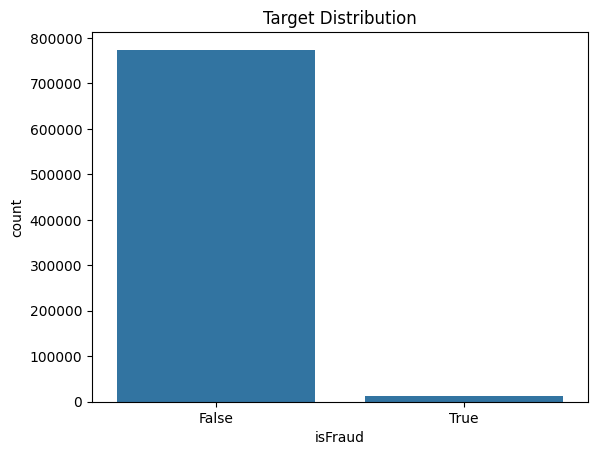

In [ ]:
# -----------------------------
# Target Distribution
# -----------------------------

target_summary = (
    df[target_col]
    .value_counts()
    .to_frame("Count")
)

target_summary["Percentage (%)"] = (
    target_summary["Count"] /
    target_summary["Count"].sum() * 100
).round(2)

display(target_summary)

# Visualization
sns.countplot(
    data=df,
    x=target_col
)

plt.title("Target Distribution")
plt.show()

## 3. Numerical variables

In [ ]:
display(
    df[numerical_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
transactionAmount,786363.0,136.985791,147.725569,0.00,33.65,87.90,191.480,2011.54
creditLimit,786363.0,10759.464459,11636.174890,250.00,5000.00,7500.00,15000.000,50000.00
availableMoney,786363.0,6250.725369,8880.783989,-1005.63,1077.42,3184.86,7500.000,50000.00
currentBalance,786363.0,4508.739089,6457.442068,0.00,689.91,2451.76,5291.095,47498.81


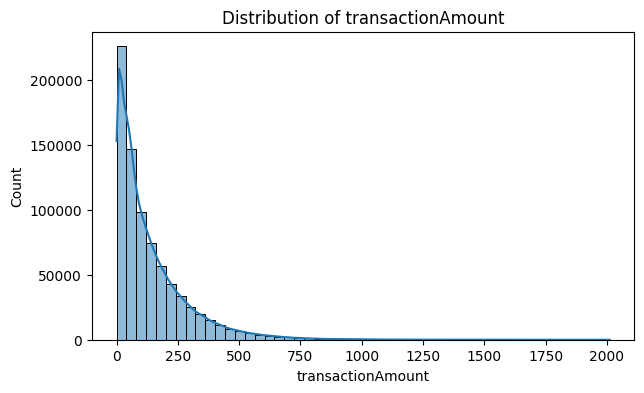

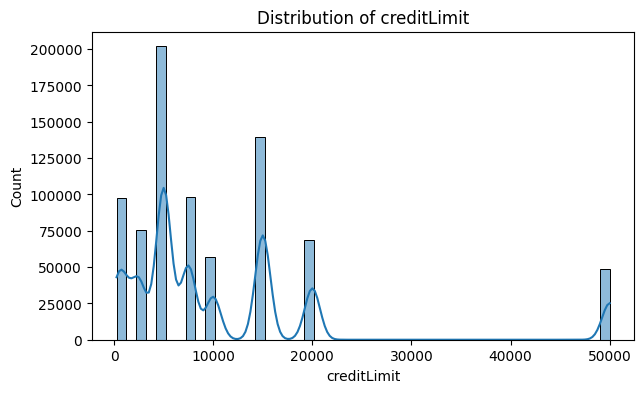

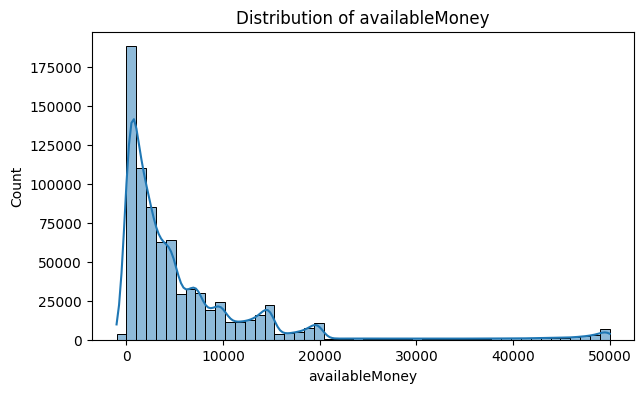

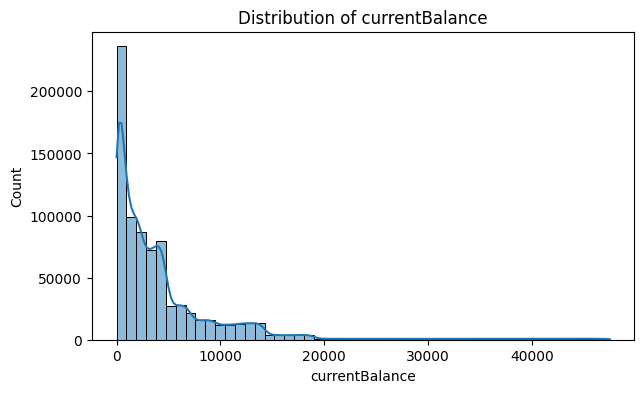

In [ ]:
# -----------------------------
# Numerical Distribution
# -----------------------------

for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.show()

*   Transaction Amount, Current Balance & Availalbe Money are right skewed
*   Credit Limit has 10 unique values, it is multi‑modal distribution with slight right skew



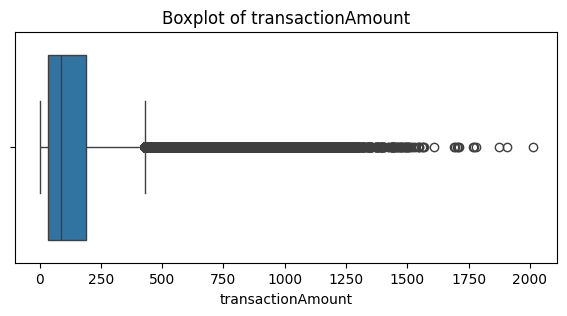

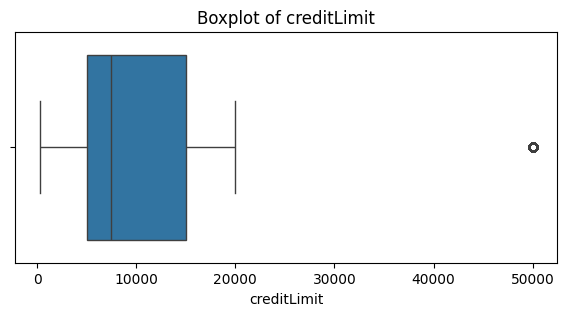

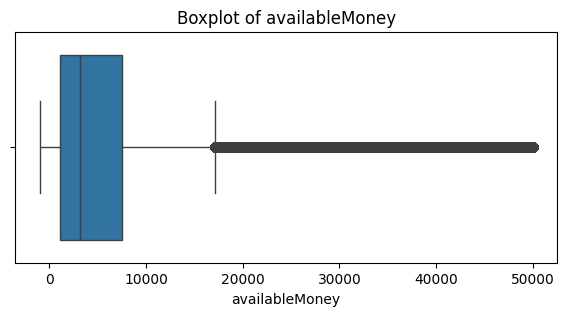

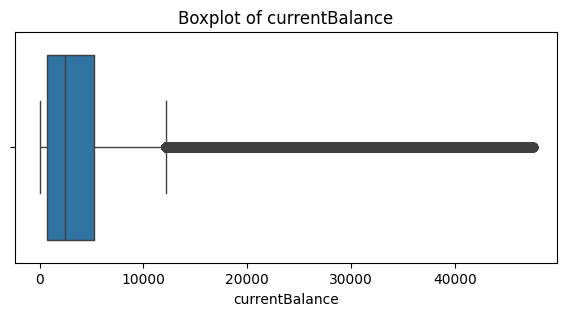

In [ ]:
# -----------------------------
# Boxplots
# -----------------------------

for col in numerical_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

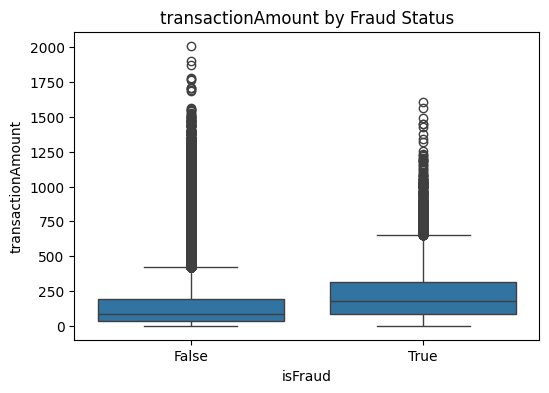

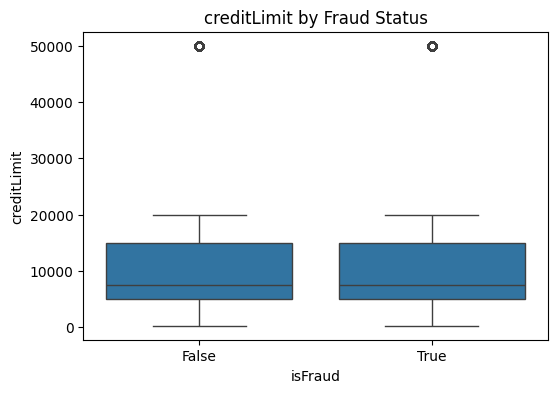

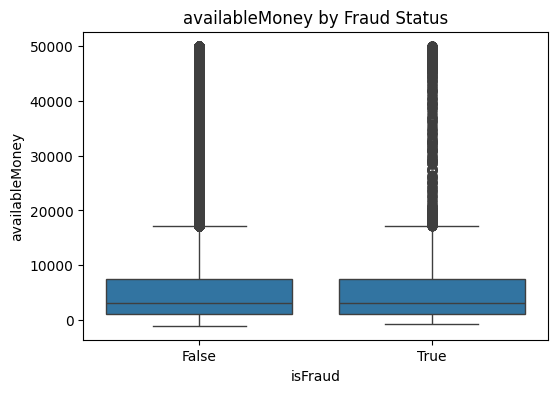

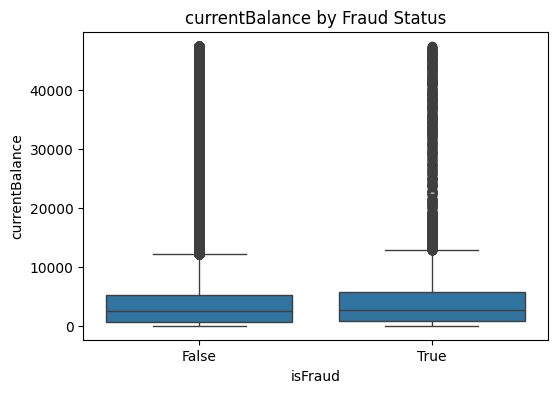

In [ ]:
# -----------------------------
# Numeric vs Target
# -----------------------------

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )

    plt.title(f"{col} by Fraud Status")
    plt.show()

In [ ]:
credit_summary = (
    df.groupby("creditLimit")["isFraud"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "fraud_rate"})
)

display(credit_summary)

,count,fraud_rate
creditLimit,,
250,34025,0.011962
500,27097,0.017161
1000,36430,0.014988
2500,75429,0.014795
5000,201863,0.017472
7500,97913,0.013175
10000,56889,0.013465
15000,139307,0.018269
20000,68629,0.013318


Transformation consideration

For creditLimit:
*   Random Forest / XGBoost - use creditLimit directly
*   Logistic Regression - try 2 options:
       * using one-hot
       * use creditLimit directly

For others:
*   consider log transformation



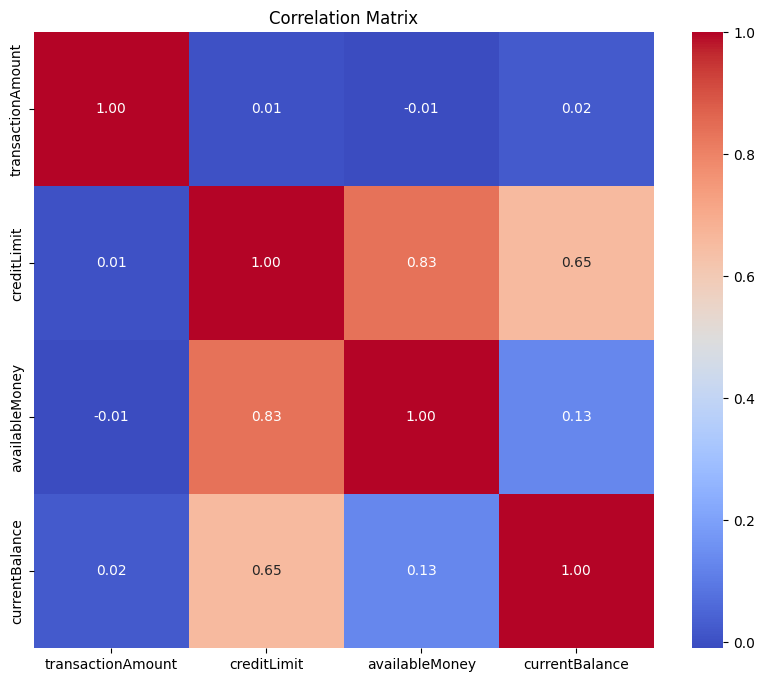

In [ ]:
num_df = df[numerical_cols + ["isFraud"]].copy()

plt.figure(figsize=(10,8))

sns.heatmap(
    num_df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
amount_bins = pd.qcut(
    num_df["transactionAmount"],
    q=10
)

amount_fraud = (
    num_df.groupby(amount_bins)["isFraud"]
      .agg(
          Count="count",
          Fraud_Rate="mean"
      )
)

amount_fraud["Fraud_Rate (%)"] = (
    amount_fraud["Fraud_Rate"] * 100
).round(2)

display(amount_fraud)


/tmp/ipykernel_7488/2238944157.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_df.groupby(amount_bins)["isFraud"]


,Count,Fraud_Rate,Fraud_Rate (%)
transactionAmount,,,
"(-0.001, 8.9]",78647,0.004310,0.43
"(8.9, 24.88]",78651,0.006332,0.63
"(24.88, 42.65]",78635,0.007630,0.76
"(42.65, 62.24]",78627,0.009628,0.96
"(62.24, 87.9]",78627,0.012337,1.23
"(87.9, 121.22]",78651,0.015334,1.53
"(121.22, 164.08]",78628,0.018009,1.80
"(164.08, 225.04]",78630,0.021976,2.20
"(225.04, 329.42]",78631,0.026186,2.62


Fraud rates increase consistently with transaction amount. Transactions in the highest decile exhibit a fraud rate of 3.62%, compared with only 0.43% in the lowest decile, indicating that higher-value transactions are substantially more likely to be fraudulent.

In [ ]:
num_df["amount_to_available_ratio"] = (
    num_df["transactionAmount"] /
    num_df["availableMoney"]).replace(0, np.nan)

num_df["amount_to_credit_ratio"] = (
    num_df["transactionAmount"] /
    num_df["creditLimit"])

num_df["credit_utilization"] = (
    num_df["currentBalance"] /
    num_df["creditLimit"]
)

num_df["remaining_credit_ratio"] = (
    num_df["availableMoney"] /
    num_df["creditLimit"]
)

num_df["insufficient_available_money"] = (
    num_df["transactionAmount"] > num_df["availableMoney"]
).astype(int)

num_df["high_limit_usage"] = (
    num_df["amount_to_credit_ratio"] >= 0.8
).astype(int)

Feature: amount_to_credit_ratio

Summary Statistics


,amount_to_credit_ratio
count,786363.000000
mean,0.056986
std,0.181698
min,0.000000
25%,0.003645
50%,0.012032
75%,0.035543
max,5.915920


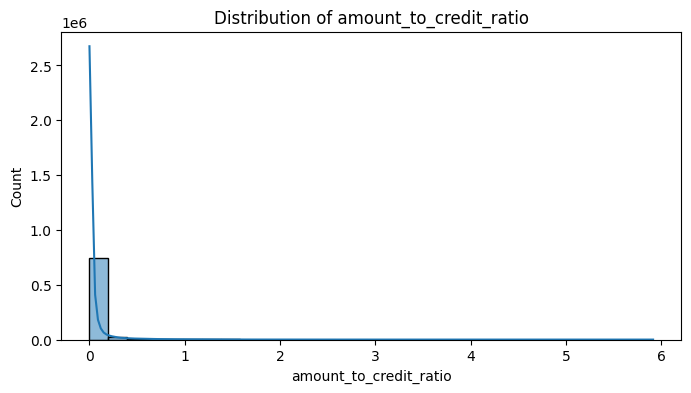


Fraud Rate by Quantile


/tmp/ipykernel_7488/3894942862.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_df.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
amount_to_credit_ratio,,
"(-0.001, 0.000947]",78682,0.55
"(0.000947, 0.00263]",78609,0.79
"(0.00263, 0.00486]",78629,1.01
"(0.00486, 0.00785]",78633,1.24
"(0.00785, 0.012]",78640,1.44
"(0.012, 0.0181]",78625,1.66
"(0.0181, 0.0279]",78636,2.05
"(0.0279, 0.0468]",78642,2.19
"(0.0468, 0.104]",78630,2.55


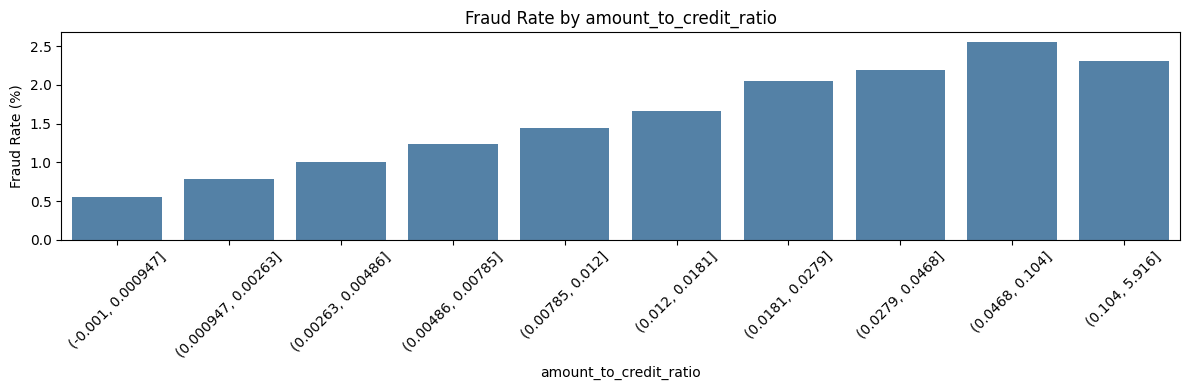

Feature: amount_to_available_ratio

Summary Statistics


,amount_to_available_ratio
count,764138.000000
mean,0.150325
std,27.440983
min,-23672.000000
25%,0.007783
50%,0.028264
75%,0.101920
max,1666.692308


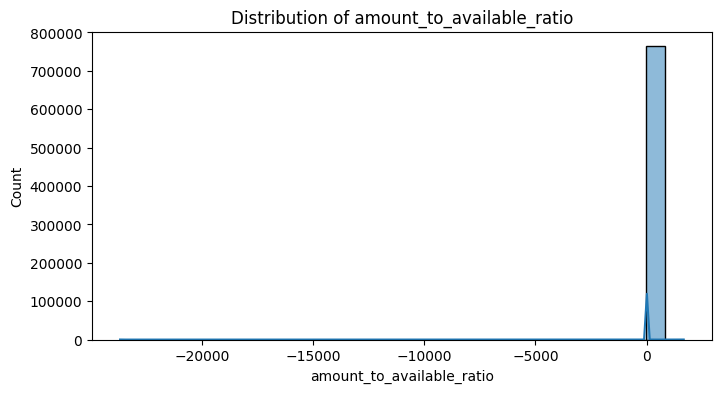


Fraud Rate by Quantile


/tmp/ipykernel_7488/3894942862.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_df.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
amount_to_available_ratio,,
"(-23672.001, 0.00221]",76414,0.59
"(0.00221, 0.00556]",76414,0.92
"(0.00556, 0.0105]",76414,1.15
"(0.0105, 0.0175]",76413,1.43
"(0.0175, 0.0283]",76414,1.59
"(0.0283, 0.0456]",76414,1.70
"(0.0456, 0.0762]",76413,1.95
"(0.0762, 0.142]",76414,2.03
"(0.142, 0.343]",76414,2.32


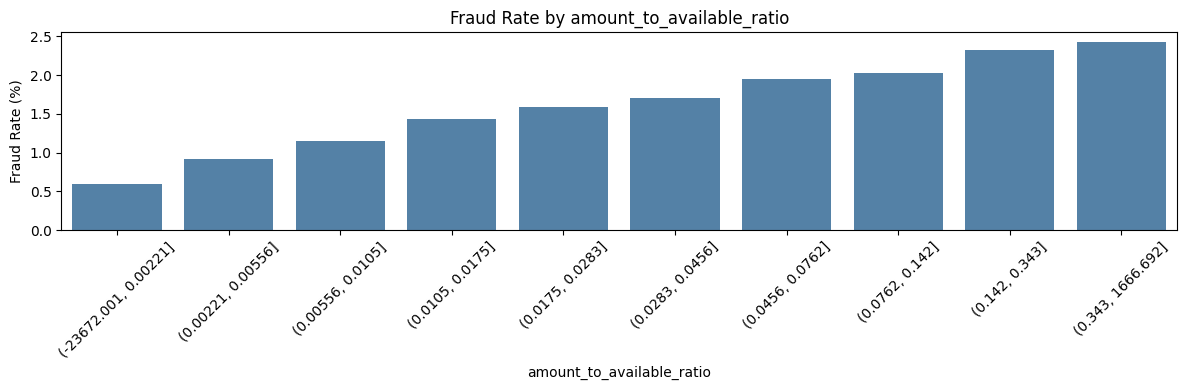

Feature: credit_utilization

Summary Statistics


,credit_utilization
count,786363.000000
mean,0.460418
std,0.308667
min,0.000000
25%,0.172856
50%,0.472975
75%,0.731203
max,4.722200


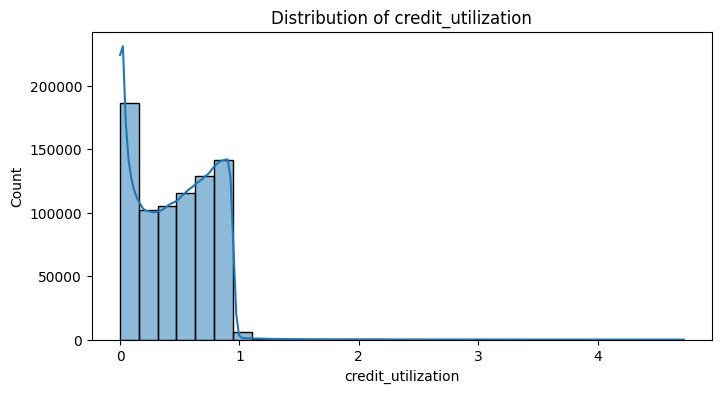


Fraud Rate by Quantile


/tmp/ipykernel_7488/3894942862.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_df.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
credit_utilization,,
"(-0.001, 0.0293]",78637,1.35
"(0.0293, 0.117]",78637,1.51
"(0.117, 0.234]",78635,1.56
"(0.234, 0.356]",78636,1.52
"(0.356, 0.473]",78637,1.63
"(0.473, 0.582]",78636,1.50
"(0.582, 0.683]",78636,1.68
"(0.683, 0.778]",78636,1.65
"(0.778, 0.867]",78636,1.69


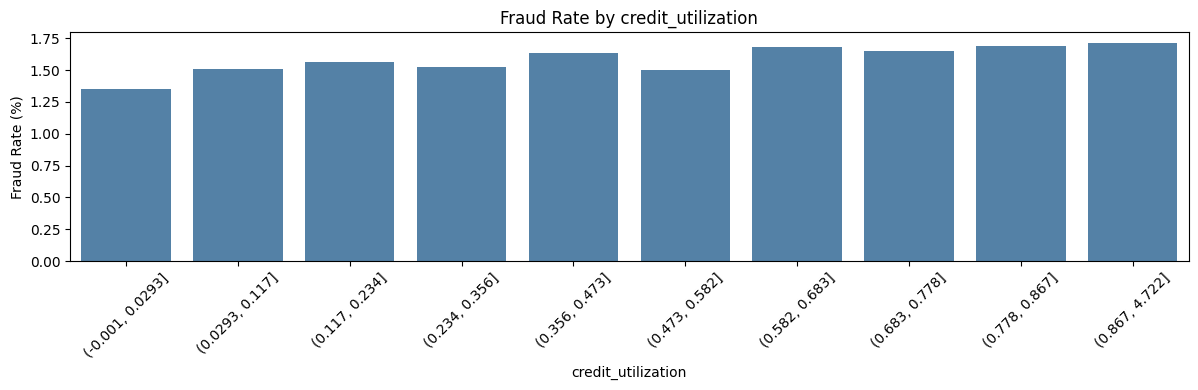

Feature: remaining_credit_ratio

Summary Statistics


,remaining_credit_ratio
count,786363.000000
mean,0.539582
std,0.308667
min,-3.722200
25%,0.268797
50%,0.527025
75%,0.827144
max,1.000000


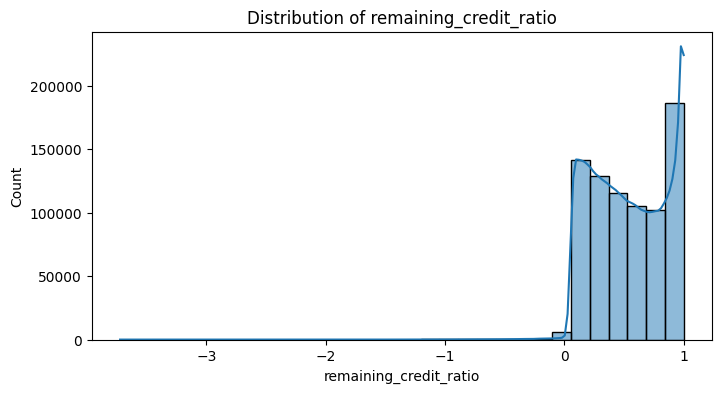


Fraud Rate by Quantile


/tmp/ipykernel_7488/3894942862.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_df.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
remaining_credit_ratio,,
"(-3.723, 0.133]",78637,1.71
"(0.133, 0.222]",78636,1.69
"(0.222, 0.317]",78636,1.65
"(0.317, 0.418]",78636,1.68
"(0.418, 0.527]",78637,1.50
"(0.527, 0.644]",78636,1.63
"(0.644, 0.766]",78636,1.52
"(0.766, 0.883]",78637,1.56
"(0.883, 0.971]",78635,1.51


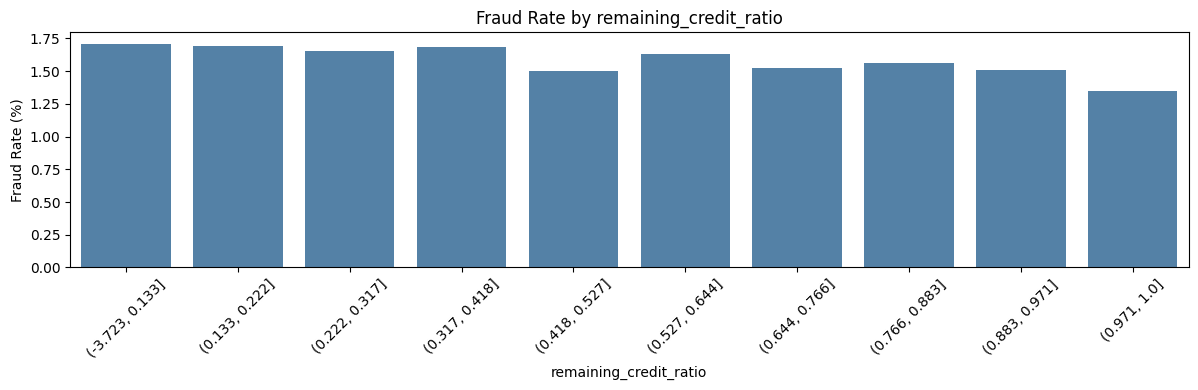

In [ ]:
new_features = [
    "amount_to_credit_ratio",
    "amount_to_available_ratio",
    "credit_utilization",
    "remaining_credit_ratio"
]

num_df[new_features] = (
    num_df[new_features]
    .replace([np.inf, -np.inf], np.nan)
)

for feature in new_features:

    print("=" * 60)
    print(f"Feature: {feature}")

    # Summary
    print("\nSummary Statistics")
    display(num_df[feature].describe())

    # Distribution
    plt.figure(figsize=(8,4))
    sns.histplot(num_df[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

    # Fraud rate by quantile
    bins = pd.qcut(
        num_df[feature],
        q=10,
        duplicates="drop"
    )

    fraud_summary = (
        num_df.groupby(bins)["isFraud"]
          .agg(
              Count="count",
              Fraud_Rate="mean"
          )
    )

    fraud_summary["Fraud_Rate (%)"] = (
        fraud_summary["Fraud_Rate"] * 100
    ).round(2)

    fraud_summary = fraud_summary.drop(columns="Fraud_Rate")

    print("\nFraud Rate by Quantile")
    display(fraud_summary)

    plt.figure(figsize=(12,4))

    sns.barplot(
        x=fraud_summary.index.astype(str),
        y=fraud_summary["Fraud_Rate (%)"],
        color="steelblue"
    )

    plt.xticks(rotation=45)
    plt.ylabel("Fraud Rate (%)")
    plt.title(f"Fraud Rate by {feature}")

    plt.tight_layout()
    plt.show()



*   Transactions with a higher transaction-to-credit-limit ratio tend to exhibit higher fraud rates.
*   Transactions with a higher transaction-to-available-credit ratio are associated with higher fraud rates.
*   Credit utilization is not a strong predictor, but might worth to include in variable selection
*   Same information from credit utilization and remaining credit ratio.



In [ ]:
num_df[
    [
        "transactionAmount",
        "amount_to_credit_ratio",
        "amount_to_available_ratio",
        "credit_utilization",
        "remaining_credit_ratio"
    ]
].corr()

,transactionAmount,amount_to_credit_ratio,amount_to_available_ratio,credit_utilization,remaining_credit_ratio
transactionAmount,1.000000,0.337173,0.005885,0.035206,-0.035206
amount_to_credit_ratio,0.337173,1.000000,0.012014,0.027714,-0.027714
amount_to_available_ratio,0.005885,0.012014,1.000000,0.002653,-0.002653
credit_utilization,0.035206,0.027714,0.002653,1.000000,-1.000000
remaining_credit_ratio,-0.035206,-0.027714,-0.002653,-1.000000,1.000000


Correlation analysis shows that the engineered ratio features are only weakly correlated with the original transaction amount and with each other, suggesting that they capture complementary information. The only exception is credit_utilization and remaining_credit_ratio, which are perfectly negatively correlated due to their mathematical relationship. Therefore, only credit_utilization is retained for subsequent modeling.

In [ ]:
num_df.groupby("insufficient_available_money")["isFraud"].agg(
    Count="count",
    Fraud_Rate="mean"
)

,Count,Fraud_Rate
insufficient_available_money,,
0,756319,0.015483
1,30044,0.023532


In [ ]:
num_df.groupby("high_limit_usage")["isFraud"].agg(
    Count="count",
    Fraud_Rate="mean"
)

,Count,Fraud_Rate
high_limit_usage,,
0,776612,0.015650
1,9751,0.026972




*   Transactions that exceed the available credit limit are associated with a higher fraud rate.
*   Transactions from accounts with high credit utilization exhibit a higher fraud rate (2.70%) than those with lower utilization (1.57%), suggesting that heavily utilized credit accounts may be associated with elevated fraud risk.



## 4. Categorical variables

In [ ]:
# -----------------------------
# Handle Missing Categories
# -----------------------------

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
# -----------------------------
# Category Distribution
# -----------------------------

for col in categorical_cols:

    print("\n" + "="*50)
    print(f"Variable: {col}")

    counts = df[col].value_counts()

    print(f"Number of categories: {len(counts)}")

    if len(counts) <= 20:

        result = pd.DataFrame({
            "Count": counts,
            "Percentage (%)": (
                counts / counts.sum() * 100
            ).round(2)
        })

        display(result)

    else:

        print("Top 10 categories:")

        result = pd.DataFrame({
            "Count": counts.head(10),
            "Percentage (%)": (
                counts.head(10) /
                counts.sum() * 100
            ).round(2)
        })

        display(result)

        print(
            f"\nCategories appearing fewer than 10 times: "
            f"{(counts < 10).sum()}"
        )


Variable: merchantCategoryCode
Number of categories: 19


,Count,Percentage (%)
merchantCategoryCode,,
online_retail,202156,25.71
fastfood,112138,14.26
entertainment,80098,10.19
food,75490,9.60
online_gifts,66238,8.42
rideshare,51136,6.50
hotels,34097,4.34
fuel,23910,3.04
subscriptions,22901,2.91



Variable: merchantName
Number of categories: 2490
Top 10 categories:


,Count,Percentage (%)
merchantName,,
Uber,25613,3.26
Lyft,25523,3.25
oldnavy.com,16992,2.16
staples.com,16980,2.16
alibaba.com,16959,2.16
apple.com,16898,2.15
walmart.com,16873,2.15
cheapfast.com,16858,2.14
ebay.com,16842,2.14



Categories appearing fewer than 10 times: 51

Variable: transactionType
Number of categories: 4


...

,Count,Percentage (%)
merchantCountryCode,,
US,778511,99.00
MEX,3143,0.40
CAN,2426,0.31
PR,1559,0.20
Unknown,724,0.09



Variable: posEntryMode
Number of categories: 6


,Count,Percentage (%)
posEntryMode,,
05,315035,40.06
09,236481,30.07
02,195934,24.92
90,19576,2.49
80,15283,1.94
Unknown,4054,0.52



Variable: posConditionCode
Number of categories: 4


,Count,Percentage (%)
posConditionCode,,
01,628787,79.96
08,149634,19.03
99,7533,0.96
Unknown,409,0.05


Transformation consideration

For Low-cardinality categorical: one-hot
*   merchantCategoryCode,transactionType,acqCountry,merchantCountryCode,posEntryMode,posConditionCode

For High-cardinality categorical:
*   LR/Random Forest/XGBoost: Target Encoding
*   CatBoost/LightGBM: use directly

In [ ]:
# -----------------------------
# Fraud Rate by Category
# -----------------------------

for col in categorical_cols:

    print("\n" + "="*50)
    print(f"Fraud Rate by {col}")

    result = (
        df.groupby(col)["isFraud"]
        .agg(
            Fraud_Rate=("mean"),
            Count=("count")
        )
        .sort_values(
            "Fraud_Rate",
            ascending=False
        )
    )

    result["Fraud_Rate (%)"] = (
        result["Fraud_Rate"] * 100
    ).round(2)

    display(
        result.drop(columns="Fraud_Rate")
        .head(15)
    )


Fraud Rate by merchantCategoryCode


,Count,Fraud_Rate (%)
merchantCategoryCode,,
airline,15412,3.46
rideshare,51136,2.49
online_retail,202156,2.44
online_gifts,66238,2.42
furniture,7432,1.39
food,75490,1.34
auto,21651,1.26
entertainment,80098,1.20
fastfood,112138,0.96



Fraud Rate by merchantName


,Count,Fraud_Rate (%)
merchantName,,
In-N-Out #949129,89,11.24
American Airlines,3139,9.40
In-N-Out #863086,96,9.38
In-N-Out #463194,96,8.33
In-N-Out #422833,110,8.18
In-N-Out #567597,89,7.87
Walgreens #475572,28,7.14
In-N-Out #17755,102,6.86
Fresh Flowers,8334,6.64



Fraud Rate by transactionType


...

,Count,Fraud_Rate (%)
merchantCountryCode,,
Unknown,724,11.33
CAN,2426,2.31
MEX,3143,2.04
PR,1559,1.73
US,778511,1.57



Fraud Rate by posEntryMode


,Count,Fraud_Rate (%)
posEntryMode,,
Unknown,4054,6.64
09,236481,2.39
90,19576,1.90
02,195934,1.75
80,15283,1.57
05,315035,0.78



Fraud Rate by posConditionCode


,Count,Fraud_Rate (%)
posConditionCode,,
Unknown,409,5.38
99,7533,3.04
01,628787,1.63
08,149634,1.29


*   Overall fraud rate from Target variable analysis is 1.58%

*   Missing values in several transaction-related categorical variables are associated with higher fraud rates. In particular, missing merchantCountryCode, posConditionCode, and posEntryMode values show substantially higher fraud rates than their non-missing counterparts. Therefore, missing values could be retained as an explicit "Unknown" category rather than removed or imputed.
*   Given that some missing categories have relative small counts, should not directly use as a conclusion during EDA



## 5. Date variables

In [ ]:
date_analysis = df[
    [
        "transactionDateTime",
        "accountOpenDate",
        "dateOfLastAddressChange",
        "currentExpDate",
        "isFraud"
    ]
].copy()

In [ ]:
def create_date_features(df):
    df = df.copy()

    # Convert to datetime
    date_cols = [
        "transactionDateTime",
        "currentExpDate",
        "accountOpenDate",
        "dateOfLastAddressChange"
    ]

    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")


    # ---------------------------------
    # Transaction time features
    # ---------------------------------

    df["transaction_year"] = (
        df["transactionDateTime"].dt.year
    )

    df["transaction_month"] = (
        df["transactionDateTime"].dt.month
    )

    df["transaction_day"] = (
        df["transactionDateTime"].dt.day
    )

    df["transaction_hour"] = (
        df["transactionDateTime"].dt.hour
    )

    df["transaction_weekday"] = (
        df["transactionDateTime"].dt.dayofweek
    )

    # weekend indicator
    df["is_weekend"] = (
        df["transaction_weekday"]
        .isin([5, 6])
        .astype(int)
    )


    # ---------------------------------
    # Account age
    # ---------------------------------

    df["account_age_days"] = (
        df["transactionDateTime"]
        - df["accountOpenDate"]
    ).dt.days


    # ---------------------------------
    # Time since address change
    # ---------------------------------

    df["days_since_address_change"] = (
        df["transactionDateTime"]
        - df["dateOfLastAddressChange"]
    ).dt.days

    # ---------------------------------
    # Address change related variables
    # ---------------------------------

    df["has_address_changed"] = (
        df["account_age_days"] != df["days_since_address_change"]
        ).astype(int)

    df["recent_address_change_30d"] = (
        df["days_since_address_change"] <= 30
        ).astype(int)

    df["recent_address_change_90d"] = (
        df["days_since_address_change"] <= 90
        ).astype(int)

    # ---------------------------------
    # Days until card expiration
    # ---------------------------------

    df["days_to_expiry"] = (
        df["currentExpDate"]
        - df["transactionDateTime"]
    ).dt.days


    return df

In [ ]:
df_date = create_date_features(date_analysis)

df_date.head()

/tmp/ipykernel_7488/2872512607.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


,transactionDateTime,accountOpenDate,dateOfLastAddressChange,currentExpDate,isFraud,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,is_weekend,account_age_days,days_since_address_change,has_address_changed,recent_address_change_30d,recent_address_change_90d,days_to_expiry
0,2016-08-13 14:27:32,2015-03-14,2015-03-14,2023-06-01,False,2016,8,13,14,5,1,518,518,0,0,0,2482
1,2016-10-11 05:05:54,2015-03-14,2015-03-14,2024-02-01,False,2016,10,11,5,1,0,577,577,0,0,0,2668
2,2016-11-08 09:18:39,2015-03-14,2015-03-14,2025-08-01,False,2016,11,8,9,1,0,605,605,0,0,0,3187
3,2016-12-10 02:14:50,2015-03-14,2015-03-14,2025-08-01,False,2016,12,10,2,5,1,637,637,0,0,0,3155
4,2016-03-24 21:04:46,2015-08-06,2015-08-06,2029-10-01,False,2016,3,24,21,3,0,231,231,0,0,0,4938


Date related variables:


*   Binary:  is_weekend, has_address_changed, recent_address_change_30d，recent_address_change_90d
*   Discrete: transaction_year，transaction_month，transaction_week，transaction_hour,transaction_weekday
*   Continuous: account_age_days,days_since_address_change,days_to_expiry



In [ ]:
# ==================================================
# Date Feature Groups
# ==================================================

binary_features = [
    "is_weekend",
    "has_address_changed",
    "recent_address_change_30d"
]

discrete_features = [
    "transaction_year",
    "transaction_month",
    "transaction_day",
    "transaction_hour",
    "transaction_weekday"
]

continuous_features = [
    "account_age_days",
    "days_since_address_change",
    "days_to_expiry"
]

Feature: is_weekend

Missing Values: 0


,Count
is_weekend,
0,562767
1,223596


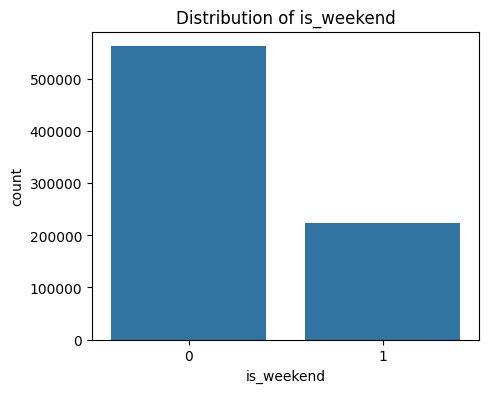


Fraud Rate:


,Count,Fraud_Rate (%)
is_weekend,,
0,562767,1.59
1,223596,1.54


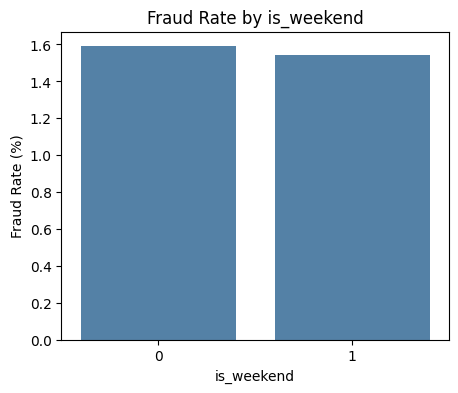

Feature: has_address_changed

Missing Values: 0


,Count
has_address_changed,
1,413287
0,373076


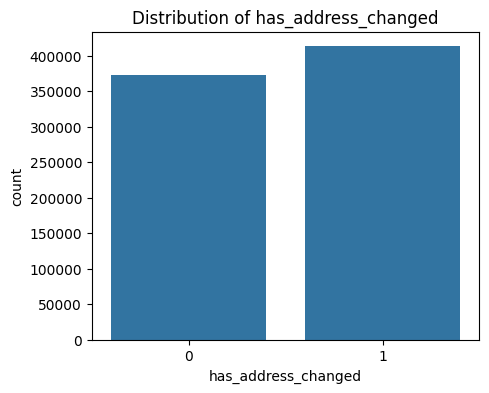


Fraud Rate:


,Count,Fraud_Rate (%)
has_address_changed,,
0,373076,1.47
1,413287,1.67


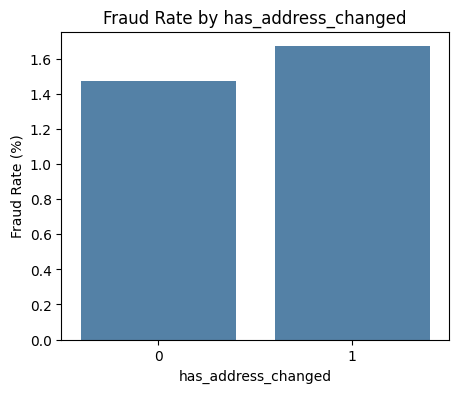

Feature: recent_address_change_30d

Missing Values: 0


,Count
recent_address_change_30d,
0,582868
1,203495


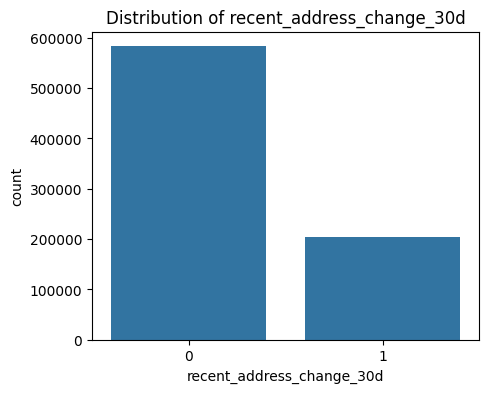


Fraud Rate:


,Count,Fraud_Rate (%)
recent_address_change_30d,,
0,582868,1.53
1,203495,1.71


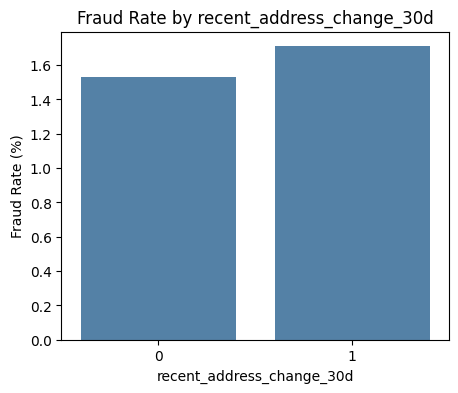

In [ ]:
# ==================================================
# Binary Features
# ==================================================

for feature in binary_features:

    print("=" * 60)
    print(f"Feature: {feature}")

    print(f"\nMissing Values: {df_date[feature].isna().sum():,}")

    display(df_date[feature].value_counts(dropna=False).to_frame("Count"))

    plt.figure(figsize=(5,4))
    sns.countplot(data=df_date, x=feature)
    plt.title(f"Distribution of {feature}")
    plt.show()

    fraud_summary = (
        df_date.groupby(feature)["isFraud"]
          .agg(
              Count="count",
              Fraud_Rate="mean"
          )
    )

    fraud_summary["Fraud_Rate (%)"] = (
        fraud_summary["Fraud_Rate"] * 100
    ).round(2)

    fraud_summary = fraud_summary.drop(columns="Fraud_Rate")

    print("\nFraud Rate:")
    display(fraud_summary)

    plt.figure(figsize=(5,4))
    sns.barplot(
        x=fraud_summary.index.astype(str),
        y=fraud_summary["Fraud_Rate (%)"],
        color="steelblue"
    )

    plt.ylabel("Fraud Rate (%)")
    plt.title(f"Fraud Rate by {feature}")
    plt.show()


A slightly higher fraud rate was observed for accounts with an address change within the past 30 days (1.71%) compared with those without a recent address change (1.53%). This feature may provide additional predictive information when combined with other variables.

Feature: transaction_year

Missing Values: 0


,Count
transaction_year,
2016,786363


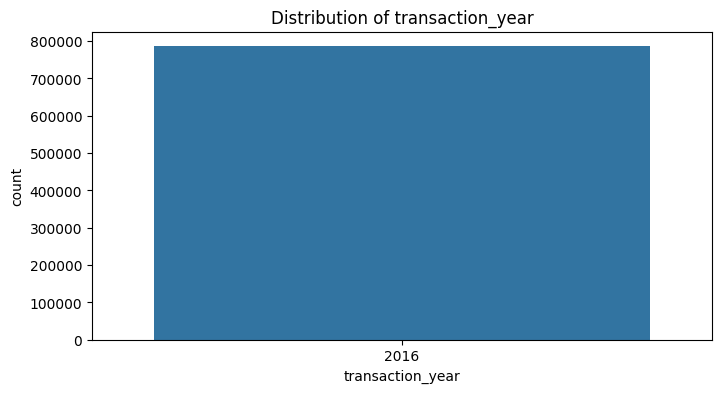


Fraud Rate:


,Count,Fraud_Rate (%)
transaction_year,,
2016,786363,1.58


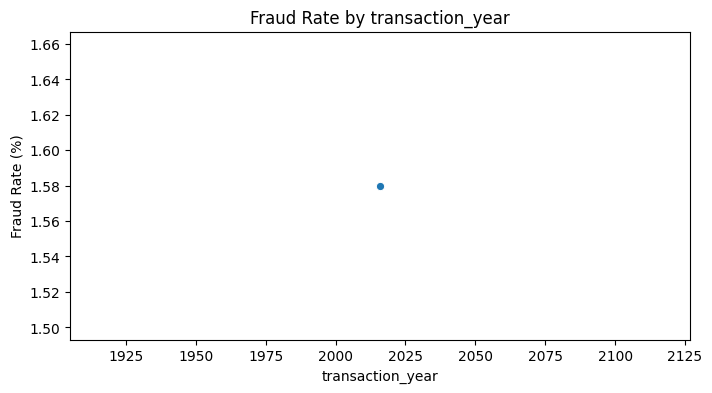

Feature: transaction_month

Missing Values: 0


,Count
transaction_month,
1,61572
2,59042
3,63927
4,62633
5,65689
6,64735
7,67159
8,68129
9,66777


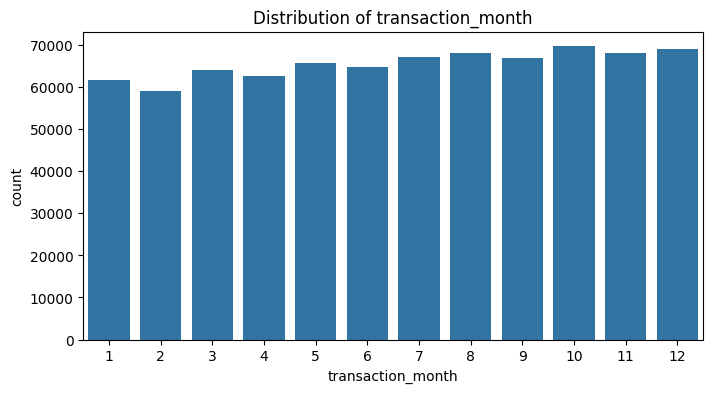


Fraud Rate:


,Count,Fraud_Rate (%)
transaction_month,,
1,61572,1.74
2,59042,1.73
3,63927,1.66
4,62633,1.60
5,65689,1.65
6,64735,1.60
7,67159,1.57
8,68129,1.51
9,66777,1.52


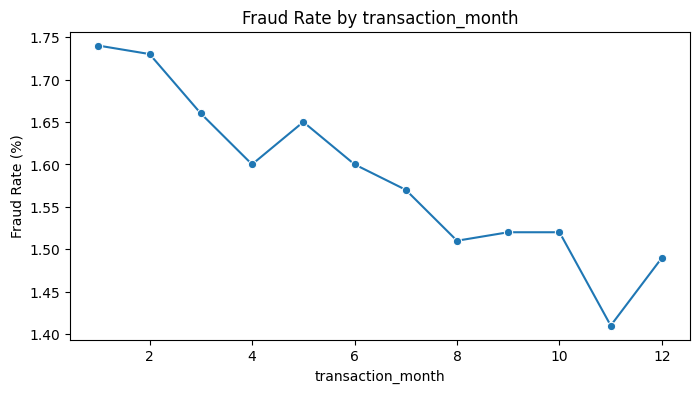

Feature: transaction_day

Missing Values: 0


,Count
transaction_day,
1,25463
2,25764
3,25631
4,25817
5,25739
6,25620
7,26075
8,25822
9,26131


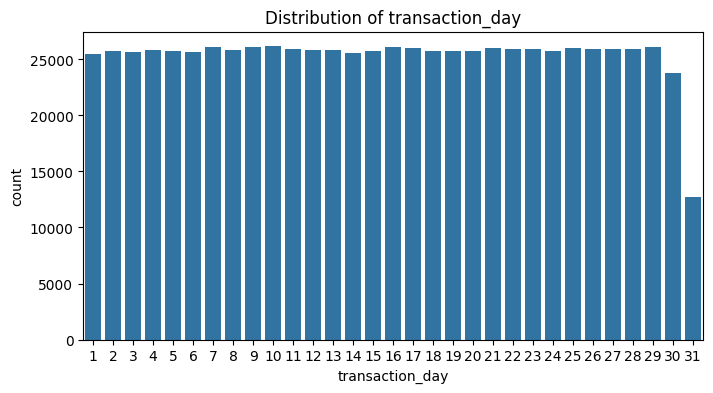


Fraud Rate:


,Count,Fraud_Rate (%)
transaction_day,,
1,25463,1.68
2,25764,1.50
3,25631,1.68
4,25817,1.57
5,25739,1.55
6,25620,1.50
7,26075,1.57
8,25822,1.57
9,26131,1.63


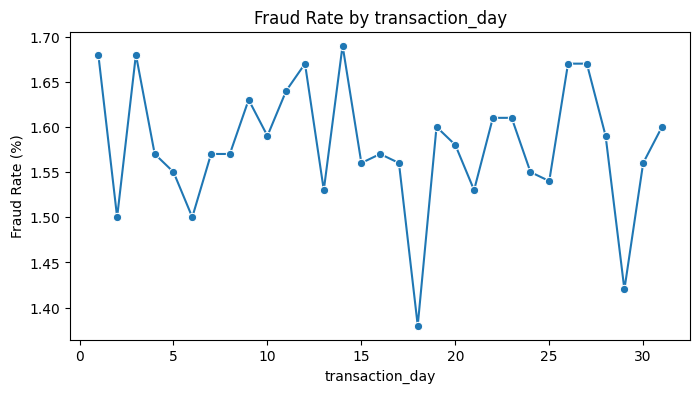

Feature: transaction_hour

Missing Values: 0


,Count
transaction_hour,
0,32854
1,32768
2,32389
3,32751
4,32689
5,32885
6,32349
7,32734
8,32901


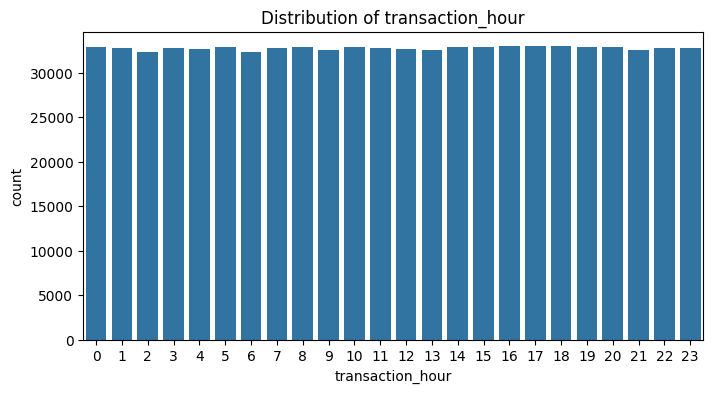


Fraud Rate:


,Count,Fraud_Rate (%)
transaction_hour,,
0,32854,1.56
1,32768,1.47
2,32389,1.52
3,32751,1.68
4,32689,1.59
5,32885,1.51
6,32349,1.59
7,32734,1.51
8,32901,1.66


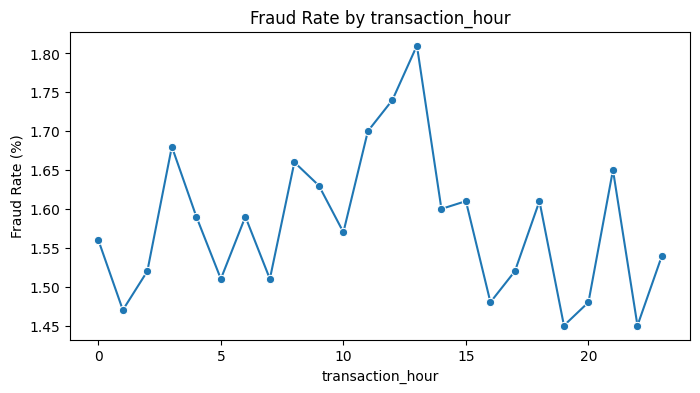

Feature: transaction_weekday

Missing Values: 0


,Count
transaction_weekday,
0,111623
1,112287
2,112011
3,112104
4,114742
5,112087
6,111509


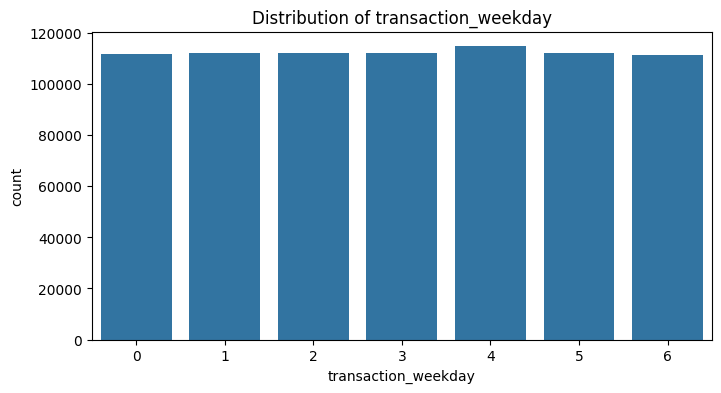


Fraud Rate:


,Count,Fraud_Rate (%)
transaction_weekday,,
0,111623,1.61
1,112287,1.57
2,112011,1.59
3,112104,1.57
4,114742,1.63
5,112087,1.53
6,111509,1.55


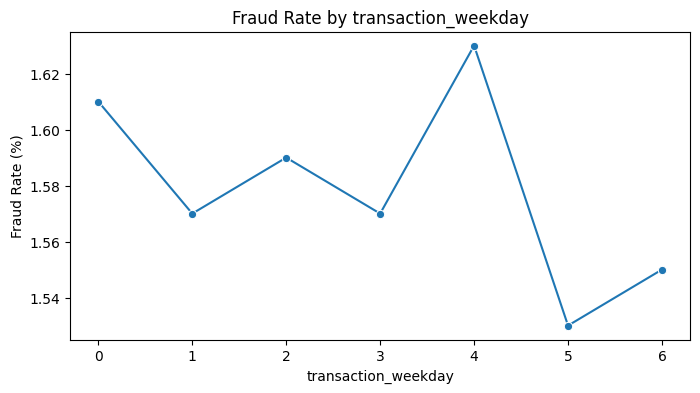

In [ ]:
# ==================================================
# Discrete Features
# ==================================================

for feature in discrete_features:

    print("=" * 60)
    print(f"Feature: {feature}")

    print(f"\nMissing Values: {df_date[feature].isna().sum():,}")

    display(
        df_date[feature]
        .value_counts()
        .sort_index()
        .to_frame("Count")
    )

    plt.figure(figsize=(8,4))
    sns.countplot(
        data=df_date,
        x=feature,
        order=sorted(df_date[feature].dropna().unique())
    )

    plt.title(f"Distribution of {feature}")
    plt.show()

    fraud_summary = (
        df_date.groupby(feature)["isFraud"]
          .agg(
              Count="count",
              Fraud_Rate="mean"
          )
    )

    fraud_summary["Fraud_Rate (%)"] = (
        fraud_summary["Fraud_Rate"] * 100
    ).round(2)

    fraud_summary = fraud_summary.drop(columns="Fraud_Rate")

    print("\nFraud Rate:")
    display(fraud_summary)

    plt.figure(figsize=(8,4))

    sns.lineplot(
        x=fraud_summary.index,
        y=fraud_summary["Fraud_Rate (%)"],
        marker="o"
    )

    plt.ylabel("Fraud Rate (%)")
    plt.title(f"Fraud Rate by {feature}")

    plt.show()



*   transaction_year has no variation and therefore provides no predictive information. It can be removed from the modeling dataset.
*   Fraud rates vary only slightly across months, with no clear seasonal pattern observed.
*   Fraud rates remain relatively stable across different hours of the day, with only minor fluctuations.
*   not considering`transaction_year`，`transaction_month`，
`transaction_day`，`transaction_weekday`，
`is_weekend` for modeling




Feature: account_age_days

Missing Values: 0

Summary Statistics


,account_age_days
count,786363.000000
mean,883.532634
std,697.504581
min,1.000000
25%,430.000000
50%,680.000000
75%,1108.000000
max,9990.000000


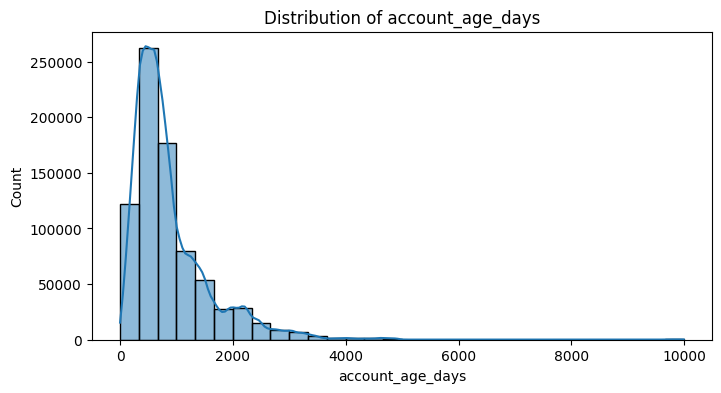


Fraud Rate by Quantile


/tmp/ipykernel_7488/3320909320.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_date.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
account_age_days,,
"(0.999, 268.0]",78742,1.55
"(268.0, 379.0]",78653,1.62
"(379.0, 479.0]",79046,1.62
"(479.0, 580.0]",78854,1.65
"(580.0, 680.0]",78302,1.64
"(680.0, 799.0]",78584,1.73
"(799.0, 967.0]",78297,1.76
"(967.0, 1280.0]",78817,1.50
"(1280.0, 1835.0]",78474,1.23


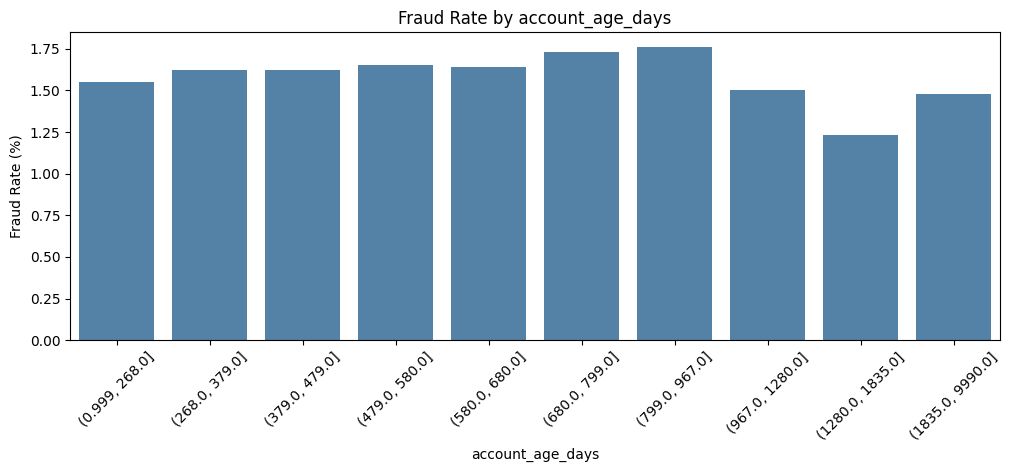

Feature: days_since_address_change

Missing Values: 0

Summary Statistics


,days_since_address_change
count,786363.000000
mean,448.299720
std,663.699614
min,0.000000
25%,28.000000
50%,159.000000
75%,612.000000
max,9990.000000


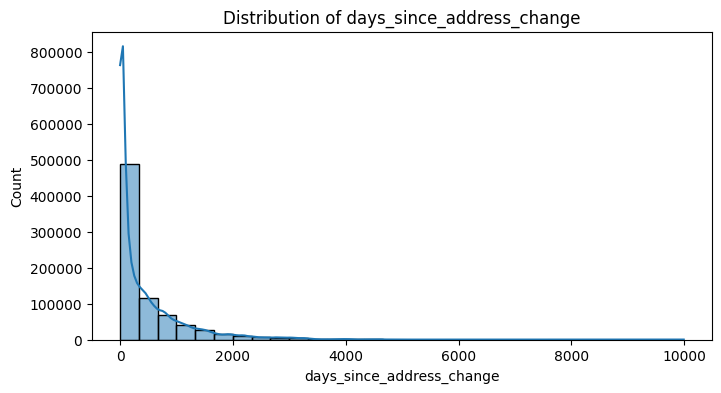


Fraud Rate by Quantile


/tmp/ipykernel_7488/3320909320.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_date.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
days_since_address_change,,
"(-0.001, 6.0]",82619,1.81
"(6.0, 19.0]",78332,1.70
"(19.0, 42.0]",76829,1.54
"(42.0, 83.0]",78166,1.76
"(83.0, 159.0]",77236,1.61
"(159.0, 299.0]",78904,1.46
"(299.0, 486.0]",78494,1.45
"(486.0, 770.0]",78733,1.57
"(770.0, 1269.0]",78486,1.46


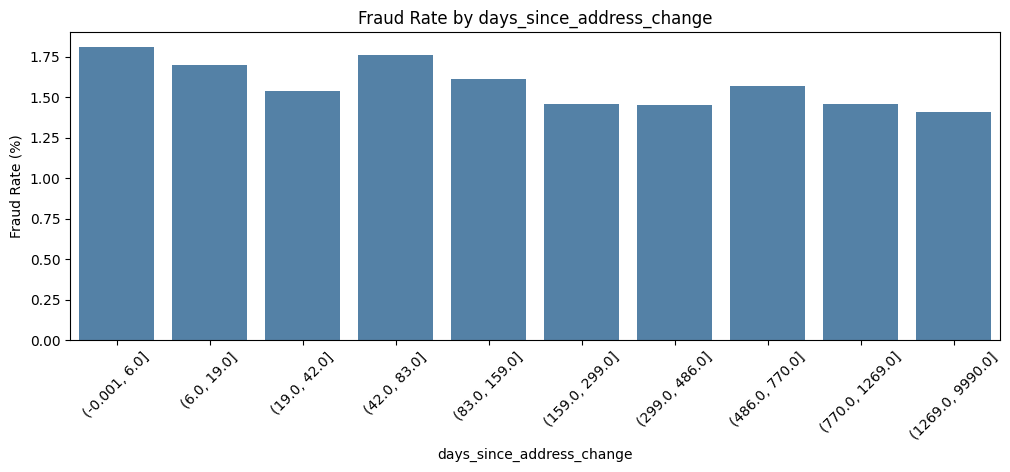

Feature: days_to_expiry

Missing Values: 0

Summary Statistics


,days_to_expiry
count,786363.000000
mean,3733.411423
std,1446.240199
min,1065.000000
25%,2484.000000
50%,3738.000000
75%,4983.000000
max,6421.000000


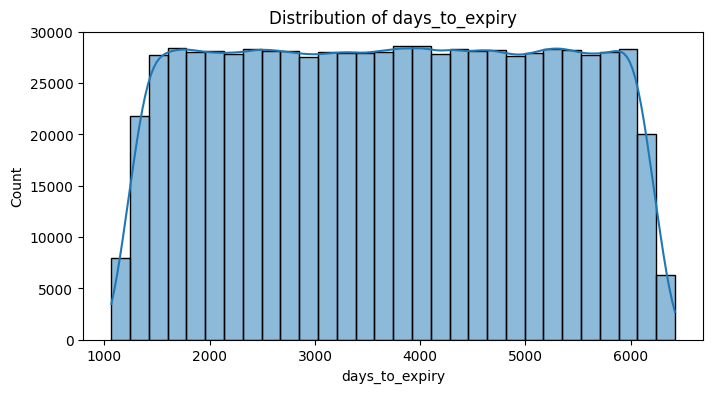


Fraud Rate by Quantile


/tmp/ipykernel_7488/3320909320.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_date.groupby(bins)["isFraud"]


,Count,Fraud_Rate (%)
days_to_expiry,,
"(1064.999, 1735.0]",78788,1.58
"(1735.0, 2234.0]",78486,1.43
"(2234.0, 2733.0]",78795,1.59
"(2733.0, 3236.0]",78498,1.64
"(3236.0, 3738.0]",78731,1.57
"(3738.0, 4233.0]",78579,1.61
"(4233.0, 4730.0]",78620,1.59
"(4730.0, 5233.0]",78643,1.55
"(5233.0, 5732.0]",78599,1.54


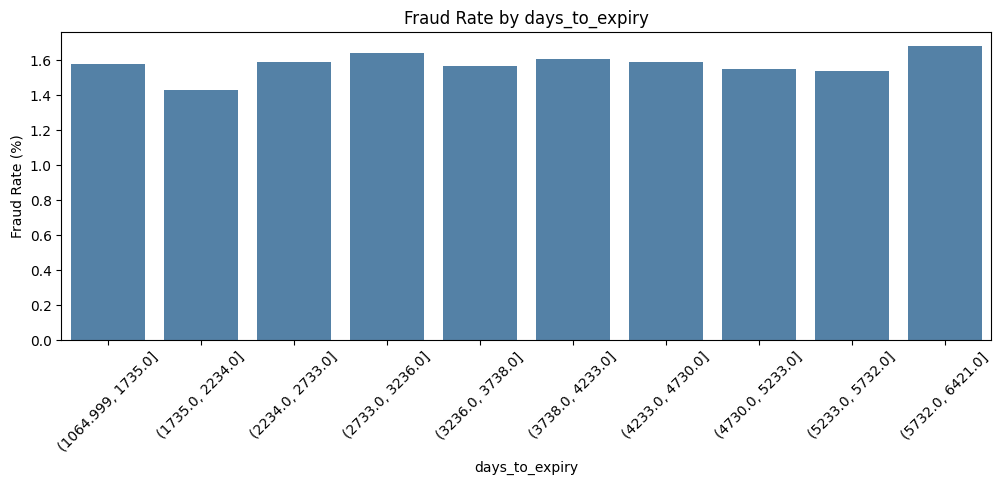

In [ ]:
# ==================================================
# Continuous Features
# ==================================================

for feature in continuous_features:

    print("=" * 60)
    print(f"Feature: {feature}")

    print(f"\nMissing Values: {df_date[feature].isna().sum():,}")

    print("\nSummary Statistics")
    display(df_date[feature].describe())

    plt.figure(figsize=(8,4))

    sns.histplot(
        df_date[feature],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.show()

    # Quantile bins
    bins = pd.qcut(
        df_date[feature],
        q=10,
        duplicates="drop"
    )

    fraud_summary = (
        df_date.groupby(bins)["isFraud"]
          .agg(
              Count="count",
              Fraud_Rate="mean"
          )
    )

    fraud_summary["Fraud_Rate (%)"] = (
        fraud_summary["Fraud_Rate"] * 100
    ).round(2)

    fraud_summary = fraud_summary.drop(columns="Fraud_Rate")

    print("\nFraud Rate by Quantile")
    display(fraud_summary)

    plt.figure(figsize=(12,4))

    sns.barplot(
        x=fraud_summary.index.astype(str),
        y=fraud_summary["Fraud_Rate (%)"],
        color="steelblue"
    )

    plt.xticks(rotation=45)

    plt.ylabel("Fraud Rate (%)")
    plt.title(f"Fraud Rate by {feature}")

    plt.show()

*   Fraud rates vary across different account ages, but no clear monotonic trend is observed. Mid-aged accounts exhibit slightly higher fraud rates than both newer and older accounts.

*   Accounts with more recent address changes generally exhibit higher fraud rates, suggesting that recent address updates may be associated with increased fraud risk.

*   No clear pattern for days_to_expiry

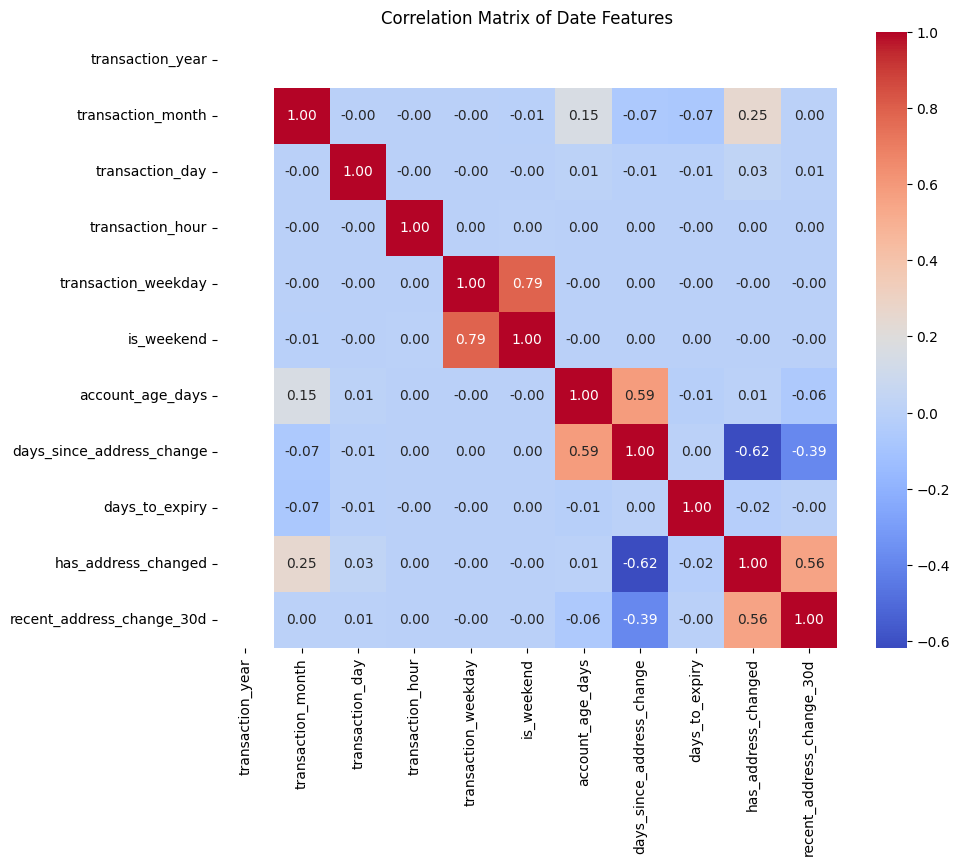

In [ ]:
date_numeric = [
    "transaction_year",
    "transaction_month",
    "transaction_day",
    "transaction_hour",
    "transaction_weekday",
    "is_weekend",
    "account_age_days",
    "days_since_address_change",
    "days_to_expiry",
    "has_address_changed",
    "recent_address_change_30d"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df_date[date_numeric].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Date Features")

plt.show()

## 6. Others

Let's check whether `accountNumber` & `customerId ` are 1-to-1.

In [ ]:
df.groupby("customerId")["accountNumber"].nunique().describe()

,accountNumber
count,5000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
df.groupby("accountNumber")["customerId"].nunique().describe()

,customerId
count,5000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
df.groupby("accountNumber").size().describe()

,0
count,5000.00000
mean,157.27260
std,655.30506
min,1.00000
25%,21.00000
50%,50.00000
75%,123.00000
max,32850.00000


Let's check if CVV is matched vs fraud

In [ ]:
df["cvv_match"] = (
    df["cardCVV"] == df["enteredCVV"]
)

df.groupby("cvv_match")["isFraud"].agg(
    Count="count",
    Fraud_Rate="mean"
)

,Count,Fraud_Rate
cvv_match,,
False,7015,0.028938
True,779348,0.015672


In [ ]:
(df["cardCVV"] != df["enteredCVV"]).mean()

np.float64(0.008920816467712749)

Although only approximately 0.9% of transactions have mismatched CVV values, these transactions exhibit a substantially higher fraud rate (2.89%) than transactions with matching CVVs (1.57%). This suggests that CVV mismatch is a potentially useful indicator of fraudulent activity.

let's check any information from `cardLast4Digits`.

In [ ]:
df["cardLast4Digits"].nunique()

5245

In [ ]:
df.groupby("cardLast4Digits").size()

,0
cardLast4Digits,
0,5578
1,23
2,495
3,71
4,11
...,...
9993,9
9994,62
9996,111


let's investigate the relationship between `transactionType` and `isFraud`.

In [ ]:
df.groupby("cardPresent")["isFraud"].agg(
    Count="count",
    Fraud_Rate="mean"
)

,Count,Fraud_Rate
cardPresent,,
False,433495,0.020674
True,352868,0.009791


Transactions where the physical card is not present exhibit a substantially higher fraud rate (2.07%) than card-present transactions (0.98%). This finding is consistent with the higher fraud risk typically associated with card-not-present transactions, such as online purchases.

let's investigate the relationship between `expirationDateKeyInMatch` and `isFraud`.

In [ ]:
df.groupby("expirationDateKeyInMatch")["isFraud"].agg(
    Count="count",
    Fraud_Rate="mean"
)

,Count,Fraud_Rate
expirationDateKeyInMatch,,
False,785320,0.015795
True,1043,0.012464


In [ ]:
pd.crosstab(
    df["expirationDateKeyInMatch"],
    df["cardPresent"],
    margins=True
)

cardPresent,False,True,All
expirationDateKeyInMatch,,,
False,433495,351825,785320
True,0,1043,1043
All,433495,352868,786363


In [ ]:
pd.crosstab(
    df["merchantCategoryCode"],
    df["cardPresent"],
    normalize="index"
) * 100

cardPresent,False,True
merchantCategoryCode,,
airline,89.962367,10.037633
auto,9.856358,90.143642
cable/phone,94.283647,5.716353
entertainment,11.418512,88.581488
fastfood,5.760759,94.239241
food,5.757054,94.242946
food_delivery,100.000000,0.000000
fuel,3.588457,96.411543
furniture,3.861679,96.138321


*   No additional information from `expirationDateKeyInMatch`

*   Merchant categories exhibit distinct transaction channel patterns. Online-related categories (e.g., online retail, mobile apps, and online subscriptions) are almost exclusively card-not-present transactions, whereas categories such as fuel, fast food, and food are predominantly card-present transactions. This suggests a strong association between merchant category and transaction channel.



# Summary of Findings

*   Fraud is highly imbalanced (~1.6%).

*   `posOnPremises`,`recurringAuthInd`,
`merchantState`,`merchantZip`,`echoBuffer`,
`merchantCity` should be dropped due to 100% missing.

*   Transaction amount shows a strong positive relationship with fraud.

*   Ratio-based features (`amount_to_credit_ratio`, `amount_to_available_ratio`) exhibit stronger discriminatory power than several original variables.

*   `credit_utilization` is retained, while `remaining_credit_ratio` is removed due to perfect collinearity.

*   `cardPresent`, `cvv_match`, and `merchantCategoryCode` demonstrate clear differences in fraud rates.

*   Temporal features (`month`, `day`, `weekday`, `weekend`) provide relatively weak predictive signals.

*   `Account age` and `days since address change` show moderate relationships with fraud risk

